# unsupervised_contour_clustering.ipynb

[Gemini reference](https://share.gemini.google/OH0lJw2upRny)

[Tuning DBSCAN parameters](https://share.gemini.google/vN3GhPCw2g3x)

In [1]:
import cv2
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import sqlite3
import json
from icecream import ic
import joblib

In [2]:
db_path = '/home/aubrey/Desktop/Efate2025/Efate2025B.db'

In [3]:
def get_spatialite_contours(db_path, table_name, geom_column, additional_filters='', limit=100):
    """
    Fetches geometries from a SpatiaLite database and converts them into 
    a list of NumPy arrays structured for OpenCV contour functions.
    
    Parameters:
        db_path (str): Path to the SpatiaLite database file.
        table_name (str): Name of the table to query.
        geom_column (str): Name of the geometry column.
        additional_filters(str): optional filters to be added to WHERE; see example below
        limit (int): Maximum number of features to fetch (default 100).
        
    Returns:
        list of np.ndarray: A list of arrays, each with shape (N, 1, 2) and dtype int32.
        
    Example for additional_filters argument: 'AND confidence>0.5 AND tree_touches_edge=0'
    """
    contours = []
    tree_ids = []
    
    # 1. Connect and query the database
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    conn.enable_load_extension(True)
    conn.load_extension('mod_spatialite')
    query = f"""
        SELECT AsGeoJSON({geom_column}), tree_id 
        FROM {table_name} 
        WHERE {geom_column} IS NOT NULL 
        {additional_filters}
        LIMIT {limit};
    """
    
    try:
        cursor.execute(query)
        rows = cursor.fetchall()
        
        # 2. Parse the results
        for row in rows:
            if not row[0]:
                continue
            
            tree_ids.append(row[1])    
            geojson_data = json.loads(row[0])
            geom_type = geojson_data.get("type")
            
            if geom_type == "Polygon":
                # Extract exterior ring coordinates
                coords = geojson_data["coordinates"][0]
                pts = np.array(coords, dtype=np.int32).reshape((-1, 1, 2))
                contours.append(pts)
                
            elif geom_type == "MultiPolygon":
                # Unroll each sub-polygon
                for polygon in geojson_data["coordinates"]:
                    coords = polygon[0]
                    pts = np.array(coords, dtype=np.int32).reshape((-1, 1, 2))
                    contours.append(pts)
                          
    finally:
        # Ensure the connection closes even if an error occurs
        conn.close()
        
    return contours, tree_ids

In [4]:
def extract_invariant_features(contour):
    """
    Returns log-transformed Hu Moments from an OpenCV contour.
    These features are invariant to translation, scale, and rotation.
    """
    moments = cv2.moments(contour)
    hu_moments = cv2.HuMoments(moments).flatten()
    log_hu = [-1.0 * np.sign(m) * np.log10(np.abs(m)) if m != 0 else 0.0 for m in hu_moments]
    return np.array(log_hu)

In [5]:

def generate_mock_contours():
    """
    Generates synthetic contours (Squares, Triangles, Circles) 
    with randomized positions, scales, and rotations for testing.
    """
    contours = []
    np.random.seed(42) # For reproducibility
    
    # Base shapes defined center-aligned
    square = np.array([[-20,-20], [20,-20], [20,20], [-20,20]], dtype=np.int32)
    triangle = np.array([[0,-25], [22,15], [-22,15]], dtype=np.int32)
    
    # Create 20 instances of each shape category
    for _ in range(20):
        scale = np.random.uniform(0.5, 2.5)
        angle = np.random.uniform(0, 2 * np.pi)
        tx, ty = np.random.randint(100, 400, size=2)
        
        rot_mat = np.array([[np.cos(angle), -np.sin(angle)], 
                            [np.sin(angle),  np.cos(angle)]])
        
        # Transform Square & Triangle
        for base_shape in [square, triangle]:
            transformed = (base_shape * scale) @ rot_mat.T + [tx, ty]
            contours.append(transformed.astype(np.int32).reshape(-1, 1, 2))
            
        # Transform Circle (approximated via contour)
        cx, cy = np.random.randint(100, 400, size=2)
        r = int(20 * scale)
        blank = np.zeros((500, 500), dtype=np.uint8)
        cv2.circle(blank, (cx, cy), r, 255, -1)
        cnts, _ = cv2.findContours(blank, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if cnts:
            contours.append(cnts[0])
            
    return contours

In [6]:
def plot_k_distance(X: np.ndarray, k: int = 4) -> None:
    """Calculates and plots the k-distance graph for a dataset to help find eps.

    Args:
        X (np.ndarray): The input data matrix of shape (n_samples, n_features).
        k (int): The number of nearest neighbors to consider. Usually set to
          min_samples or min_samples - 1. Defaults to 4.

    Returns:
        None: Displays a matplotlib plot.
    """
    # Fit the nearest neighbors model
    # n_neighbors is k + 1 because the closest point to any node is itself (distance 0)
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X)
    distances, indices = nbrs.kneighbors(X)

    # Sort the distances to the k-th nearest neighbor (index k, since index 0 is the point itself)
    k_distances = np.sort(distances[:, k])

    # Plot the sorted distances
    plt.figure(figsize=(8, 5))
    plt.plot(k_distances, label=f"{k}-th Nearest Neighbor Distance")

    plt.title(f"k-Distance Graph (k={k})")
    plt.xlabel("Points sorted by distance")
    plt.ylabel(f"{k}-th Nearest Neighbor Distance")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()
    plt.show()

# Main

In [7]:
# --- Main Pipeline ---

# 1. Load or generate contours
# Replace this with your actual list of OpenCV contours!
# contours = generate_mock_contours()

contours, tree_ids = get_spatialite_contours(
    db_path='/home/aubrey/Desktop/Efate2025/Efate2025B.db',
    table_name='trees',
    geom_column='tree_poly',
    additional_filters='AND confidence>0.5 AND tree_touches_edge=0 AND pixel_count > 4000',
    limit=1000000   
)

In [8]:
ic(type(tree_ids), ic(len(tree_ids)))

ic| len(tree_ids): 4883
ic| type(tree_ids): <class 'list'>, ic(len(tree_ids)): 4883


(list, 4883)

In [9]:
# 2. Extract invariant features
features = np.array([extract_invariant_features(c) for c in contours])

# PLOT

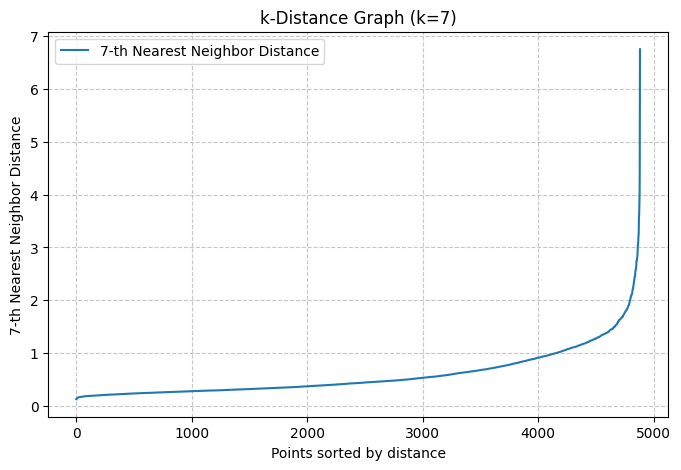

In [10]:
plot_k_distance(features, k=7)

In [11]:
# 3. Scale features (Critical step for distance-based clustering)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [12]:
ic(type(scaled_features), scaled_features.shape)

ic| type(scaled_features): <class 'numpy.ndarray'>
    scaled_features.shape: (4883, 7)


(numpy.ndarray, (4883, 7))

In [13]:
# 4. Perform Unsupervised Clustering with DBSCAN
# eps: max distance between two samples to be considered in the same neighborhood
# min_samples: minimum shapes to form a dense cluster nucleus
# starting point for eps is 0.5; for min_samples=3
dbscan = DBSCAN(eps=0.2)
cluster_labels = dbscan.fit_predict(scaled_features)

unique_labels = set(cluster_labels)
n_clusters = len(unique_labels) - (1 if -1 in cluster_labels else 0)
print(f"Automatically identified {n_clusters} shape clusters.")
print(f"Detected anomalies/noise elements: {list(cluster_labels).count(-1)}")

cluster_names= np.unique(cluster_labels).tolist()
# cluster_labels contains a list of labels ranging from -1 to n where -1 is a special class for "Noise/Unclassified"
# bincount does not allow negative integers, so we just add 1 to each label value
# just remember to use cluster_names as the index
cluster_counts = np.bincount(cluster_labels + 1).tolist()

ic(cluster_names)
ic(cluster_counts);

Automatically identified 21 shape clusters.
Detected anomalies/noise elements: 1431


ic| cluster_names: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
ic| cluster_counts: [1431, 3317, 8, 21, 11, 5, 4, 9, 5, 5, 9, 6, 5, 6, 5, 5, 6, 5, 5, 5, 5, 5]


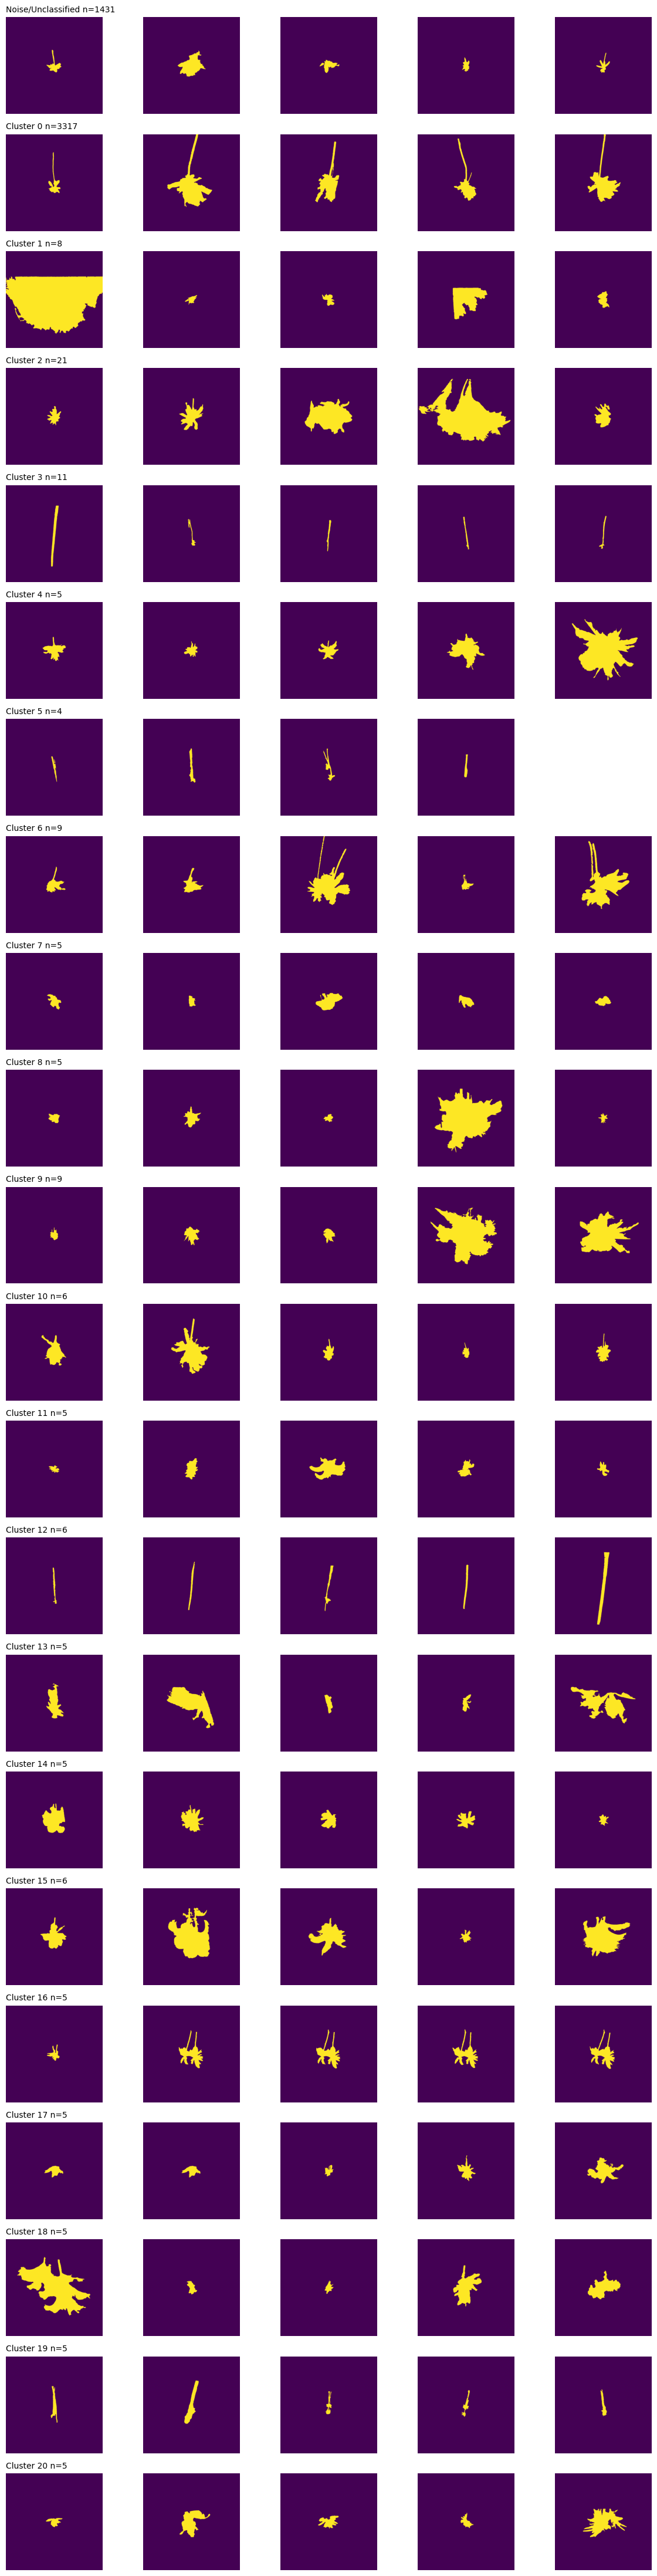

In [14]:
# 5. Visual Inspection Tool
# We'll plot examples from each identified cluster
plt.figure(figsize=(12, 2 * len(unique_labels)))

for row_idx, label in enumerate(sorted(unique_labels)):
    # Grab indices belonging to current cluster
    indices = np.where(cluster_labels == label)[0]
    title_text = f"Cluster {label} n={cluster_counts[row_idx]}" if label != -1 else f"Noise/Unclassified n={cluster_counts[row_idx]}"
    
    # Plot up to 5 examples per cluster side-by-side
    for col_idx, img_idx in enumerate(indices[:5]):
        plt.subplot(len(unique_labels), 5, row_idx * 5 + col_idx + 1)
        
        # Create a mini binary canvas to draw the contour
        canvas = np.zeros((1000, 1000), dtype=np.uint8)
        
        # Normalize contour position to center of the visualization thumbnail
        cnt = contours[img_idx].copy()
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cnt = cnt - [cx, cy] + [500, 500] # shifts center to (50,50)
            
        cv2.drawContours(canvas, [cnt], -1, 255, thickness=cv2.FILLED)
        plt.imshow(canvas)
        plt.axis('off')
        if col_idx == 0:
            plt.title(title_text, fontsize=10, loc='left')

plt.tight_layout()
plt.show()

# SAVE MODEL

In [15]:
def save_model():

    # Extract the core samples and their corresponding labels directly from DBSCAN
    core_samples_scaled = dbscan.components_
    core_labels = cluster_labels[dbscan.core_sample_indices_]

    # Save everything as a single production dictionary
    model_artifacts = {
        'scaler': scaler,
        'eps': dbscan.eps,
        'core_samples': core_samples_scaled,
        'core_labels': core_labels
    }

    joblib.dump(model_artifacts, 'dbscan_shape_production.pkl')
    print("Pure DBSCAN profile saved successfully!")

# save_model()

# LOAD MODEL

In [16]:
def load_model():
    artifacts = joblib.load('dbscan_shape_production.pkl')
    scaler = artifacts['scaler']
    eps = artifacts['eps']
    core_samples = artifacts['core_samples']
    core_labels = artifacts['core_labels']
    
    return scaler, eps, core_samples, core_labels

# scaler, eps, core_samples, core_labels = load_model()

In [17]:
def classify_contour(new_contour):
    # 2. Process your new incoming contour
    # (Assuming 'new_contour' is detected via cv2.findContours)
    new_features = extract_invariant_features(new_contour)
    new_features_scaled = scaler.transform(new_features.reshape(1, -1))

    # 3. Apply Pure DBSCAN Math: Calculate Euclidean distance to all core points
    # Using broadcasted numpy operations for speed
    distances = np.linalg.norm(core_samples - new_features_scaled, axis=1)

    # Find the single closest core point
    closest_idx = np.argmin(distances)
    min_distance = distances[closest_idx]

    # 4. Assign cluster based on density threshold (eps)
    if min_distance <= eps:
        assigned_cluster = core_labels[closest_idx].item()
        # print(f"Shape classified into Cluster: {assigned_cluster} (Distance: {min_distance:.3f} <= eps)")
    else:
        assigned_cluster = -1
        # print(f"Shape is an Outlier / Noise. Closest core point was {min_distance:.3f} away (eps limit is {eps})")
        
    return assigned_cluster

In [18]:
def get_spatialite_contours2(conn, query):
    """
    Fetches geometries from a SpatiaLite database and converts them into 
    a list of NumPy arrays structured for OpenCV contour functions.
    
    Parameters:
        conn: connection to SpatiaLite database
        query: SQL query
        
    Returns:
        list of np.ndarray: A list of arrays, each with shape (N, 1, 2) and dtype int32.
    """
    cursor = conn.cursor()
    contours = []
    try:
        cursor.execute(query)
        rows = cursor.fetchall()
        
        # 2. Parse the results
        for row in rows:
            if not row[0]:
                continue
                
            geojson_data = json.loads(row[0])
            geom_type = geojson_data.get("type")
            
            if geom_type == "Polygon":
                # Extract exterior ring coordinates
                coords = geojson_data["coordinates"][0]
                pts = np.array(coords, dtype=np.int32).reshape((-1, 1, 2))
                contours.append(pts)
                
            elif geom_type == "MultiPolygon":
                # Unroll each sub-polygon
                for polygon in geojson_data["coordinates"]:
                    coords = polygon[0]
                    pts = np.array(coords, dtype=np.int32).reshape((-1, 1, 2))
                    contours.append(pts)                   
    finally:
        # Ensure the cursor closes even if an error occurs
        cursor.close()
        
    return contours    

# Update shape_class field in trees table using the DBSCAN model


In [21]:
db_path = '/home/aubrey/Desktop/Efate2025/Efate2025B.db'

# load model
scaler, eps, core_samples, core_labels = load_model()

# open database
conn = sqlite3.connect(db_path)
conn.enable_load_extension(True)
conn.load_extension('mod_spatialite')

# set shape_class to NULL for all records
try:
    conn.execute('UPDATE trees SET shape_class =  NULL')
    conn.commit()
except:
    print('error occurred when setting shape_class to NULL')
    pass

# Get list of tree_ids to be processed
sql = """ 
    SELECT tree_id
    FROM trees
    WHERE 
        confidence>0.5 
        AND tree_touches_edge=0 
        AND pixel_count > 2000
"""
cursor = conn.cursor()
cursor.execute(sql)
rows = cursor.fetchall()

for row in rows:
    tree_id = row[0]
    
    # get tree contour
    sql = f'SELECT AsGeoJSON(tree_poly) FROM trees WHERE tree_id={tree_id}'
    contours = get_spatialite_contours2(conn, sql)
    contour = contours[0]

    # get shape class
    shape_class = classify_contour(contour)
    
    # update record
    sql = f'UPDATE trees SET shape_class={shape_class} WHERE tree_id={tree_id};'
    conn.execute(sql)
conn.commit()

# Add shape_class to trees table

In [22]:
scaler, eps, core_samples, core_labels = load_model()

conn = sqlite3.connect(db_path)
try:
    conn.execute('ALTER TABLE trees ADD COLUMN shape_class INTEGER')
    conn.commit()
except:
    pass

conn = sqlite3.connect(db_path)
try:
    conn.execute('UPDATE trees SET shape_class =  NULL')
    conn.commit()
except:
    pass

sql = f""" 
UPDATE trees 
SET shape_class = cuts
WHERE confidence>0.5 AND tree_touches_edge=0 AND pixel_count > 4000
"""
cursor = conn.cursor()
cursor.execute(sql)
rows = cursor.fetchall()
cursor.close()

for row in rows:
    print(row)

conn.execute(sql)
conn.commit()
conn.close()

ic('FINISHED')

ic| 'FINISHED'


'FINISHED'

In [ ]:
scaler, eps, core_samples, core_labels = load_model()

# Connect to the SQLite database
conn = sqlite3.connect('db_path')
cursor = conn.cursor()

# Ensure shape_class column exists
try:
    conn.execute('ALTER TABLE trees ADD COLUMN shape_class INTEGER')
    conn.commit()
except:
    pass

# Set value of shape_class to NULL for all rows
conn = sqlite3.connect(db_path)
try:
    conn.execute('UPDATE trees SET shape_class =  NULL')
    conn.commit()
except:
    pass

# 1. Fetch only the selected rows needing processing
cursor = conn.cursor()
cursor.execute("SELECT tree_id, tree_poly FROM trees WHERE confidence>0.5 AND tree_touches_edge=0 AND pixel_count > 4000 LIMIT 10")
rows = cursor.fetchall()

# 2. Map the rows to calculate the new values
updated_data = [
    (classify_contour(tree_poly), row_id) 
    for row_id, tree_poly in rows
]

# 3. Batch update the database efficiently in one go
cursor.executemany(
    "UPDATE target_table SET column_to_update = ? WHERE id = ?", 
    updated_data
)

# Commit the changes and close the connection
conn.commit()
conn.close()

ic('finished')

In [ ]:
contours, tree_ids = get_spatialite_contours(
    db_path=db_path, 
    table_name='trees', 
    geom_column='tree_poly', 
    additional_filters='AND confidence>0.5 AND tree_touches_edge=0 AND pixel_count > 4000', 
    limit=1000000
)

conn = sqlite3.connect(db_path)
cursor = conn.cursor()
for i, contour in enumerate(contours):
    shape_class = classify_contour(contour)
    # ic(tree_ids[i], shape_class)
    cursor.execute(f'UPDATE trees SET shape_class = {shape_class} WHERE tree_id = {tree_ids[i]}')
conn.commit()
conn.close()

In [ ]:
import sqlite3
import cv2
import numpy as np
from shapely import wkt


def load_spatialite_extension(conn):
    """Loads the SpatiaLite extension into the sqlite3 connection."""
    conn.enable_load_extension(True)
    # Adjust the path/name based on your OS (e.g., 'mod_spatialite', 'libspatialite.so')
    try:
        conn.load_extension("mod_spatialite")
    except sqlite3.OperationalError:
        # Fallback for some environments if already statically linked or named differently
        pass


def wkt_to_opencv_contour(wkt_string):
    """Converts a WKT Polygon string to an OpenCV compatible NumPy array."""
    # Parse WKT using shapely
    poly = wkt.loads(wkt_string)

    # Extract the exterior coordinates (and convert to a list of tuples/points)
    # OpenCV contours drop the redundant closing point that GIS polygons have
    coords = list(poly.exterior.coords)[:-1]

    # Convert to numpy array and reshape to (N, 1, 2) as required by OpenCV
    # Note: Ensure these match your pixel space (round/cast to int32)
    contour = np.array(coords, dtype=np.int32).reshape((-1, 1, 2))

    return contour


def fetch_contours_from_db(db_path):
    # 1. Connect to the SpatiaLite database
    conn = sqlite3.connect(db_path)
    load_spatialite_extension(conn)
    cursor = conn.cursor()

    # 2. Fetch the geometries as WKT text
    # Assuming your table is 'contours_table' and geometry column is 'geom'
    # ST_AsText ensures you get the clean WKT string
    query = "SELECT ST_AsText(geom) FROM contours_table;"
    cursor.execute(query)

    opencv_contours = []

    for row in cursor.fetchall():
        wkt_string = row[0]
        if wkt_string:
            contour = wkt_to_opencv_contour(wkt_string)
            opencv_contours.append(contour)

    conn.close()
    return opencv_contours


# --- Example Usage ---
# contours = fetch_contours_from_db("your_spatialite_db.sqlite")
#
# # Now you can use them directly in OpenCV, for example, drawing them:
# image = np.zeros((1080, 1920, 3), dtype=np.uint8)
# cv2.drawContours(image, contours, -1, (0, 255, 0), 2)

In [ ]:
import sqlite3
import cv2
import numpy as np
from shapely import wkt


def load_spatialite_extension(conn):
    """Loads the SpatiaLite extension into the sqlite3 connection."""
    conn.enable_load_extension(True)
    # Adjust the path/name based on your OS (e.g., 'mod_spatialite', 'libspatialite.so')
    try:
        conn.load_extension("mod_spatialite")
    except sqlite3.OperationalError:
        # Fallback for some environments if already statically linked or named differently
        pass


def wkt_to_opencv_contour(wkt_string):
    """Converts a WKT Polygon string to an OpenCV compatible NumPy array."""
    # Parse WKT using shapely
    poly = wkt.loads(wkt_string)

    # Extract the exterior coordinates (and convert to a list of tuples/points)
    # OpenCV contours drop the redundant closing point that GIS polygons have
    coords = list(poly.exterior.coords)[:-1]

    # Convert to numpy array and reshape to (N, 1, 2) as required by OpenCV
    # Note: Ensure these match your pixel space (round/cast to int32)
    contour = np.array(coords, dtype=np.int32).reshape((-1, 1, 2))

    return contour


def fetch_contours_from_db(db_path):
    # 1. Connect to the SpatiaLite database
    conn = sqlite3.connect(db_path)
    load_spatialite_extension(conn)
    cursor = conn.cursor()

    # 2. Fetch the geometries as WKT text
    # Assuming your table is 'contours_table' and geometry column is 'geom'
    # ST_AsText ensures you get the clean WKT string
    query = "SELECT ST_AsText(geom) FROM contours_table;"
    cursor.execute(query)

    opencv_contours = []

    for row in cursor.fetchall():
        wkt_string = row[0]
        if wkt_string:
            contour = wkt_to_opencv_contour(wkt_string)
            opencv_contours.append(contour)

    conn.close()
    return opencv_contours


# --- Example Usage ---
contours = fetch_contours_from_db("your_spatialite_db.sqlite")
#
# # Now you can use them directly in OpenCV, for example, drawing them:
# image = np.zeros((1080, 1920, 3), dtype=np.uint8)
# cv2.drawContours(image, contours, -1, (0, 255, 0), 2)